# Clean Model Training Notebook
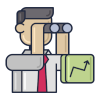

## Clean Model Training Overview

This notebook walks through training a **clean** NHiTS forecasting model on our preprocessed time series.

---

### 🎯 Objectives
- Load and preprocess the cleaned dataset  
- Scale features for stable optimization  
- Initialize a NHiTSModel with sensible hyperparameters  
- Train on GPU if available  

---

### 🛠️ Key Steps

1. **Data Loading & Conversion** 
   - Read `clean_train_data.csv` into a DataFrame  
   - Convert to a Darts `TimeSeries` (float32)  

2. **Device Configuration** 
   - Detect CUDA and set `pl_trainer_kwargs` for GPU acceleration  
   - Fall back to CPU if no GPU is found  

3. **Data Scaling** 
   - Apply a `Scaler` transformer to normalize each channel  

4. **Model Initialization**   
   - `input_chunk_length=400`, `output_chunk_length=400`  
   - `num_stacks=4`, `num_blocks=4`, `num_layers=2`  
   - Learning rate = `1e-4`, random seed = `42`  

5. **Model Fitting** 🏋️
   - Fit for `n_epochs=2` (for quick iteration; increase for production)  
   - Our clean model was trained for up to 100 epochs, with early stopping based on the training loss.
---

### 🌟 Highlights & Takeaways

- **Feature Scaling** improves convergence and prevents gradient issues.  
- **GPU Training** can drastically cut down fit time (where available).  
- The **multi-scale architecture** (stacks/blocks) in NHiTS captures both short- and long-term patterns.  
- **Quick demo with 2 epochs**—bump this up for a better model!  

---


## Install Dependencies

In [ ]:
#!pip install --quiet torch==2.6.0 darts==0.33.0 scikit-learn==1.6.1 2>/dev/null

## Imports

In [ ]:
import warnings

import numpy as np
import pandas as pd
import torch

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import NHiTSModel

# Suppress all warnings for a cleaner notebook output
warnings.filterwarnings("ignore")


## Data

In [ ]:
# 1) Read the cleaned CSV into a pandas DataFrame
train_data_df = pd.read_csv(
    "./data/clean_train_data.csv",
    index_col=0
)

# 2) Convert the DataFrame to a Darts TimeSeries and cast to float32
train_data_series = (
    TimeSeries.from_dataframe(train_data_df)
    .astype(np.float32)
)


## Model

In [ ]:
# 1) Detect GPU availability for PyTorch Lightning
if torch.cuda.is_available():
    pl_trainer_kwargs = {
        "accelerator": "gpu",
        "devices": "auto"
    }
    print("✅ GPU detected: training on GPU")
else:
    pl_trainer_kwargs = {}
    print("⚠️ GPU not detected: training on CPU")

# 2) Set up data scaling transformer
encoders = {
    "transformer": Scaler()
}


In [ ]:
model = NHiTSModel(
    input_chunk_length=400,
    output_chunk_length=400,
    n_epochs=2,
    random_state=42,
    pl_trainer_kwargs=pl_trainer_kwargs,  # device configuration (GPU/CPU)
    add_encoders=encoders,               # data scaling transformer
    num_stacks=4,
    num_blocks=4,
    num_layers=2,
    optimizer_kwargs={"lr": 1e-4}        # learning rate
)


In [ ]:
model.fit(train_data_series)